In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

2026-05-07 09:39:12.518774: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 09:39:12.546055: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train:", X_train.shape)
print("Test:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 178s 1us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


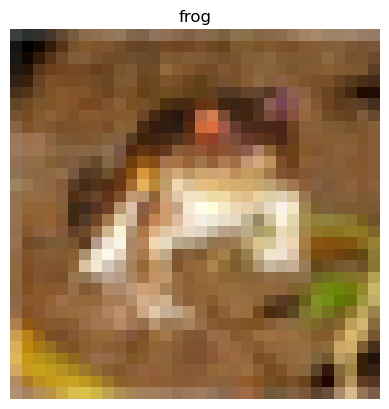

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 66ms/step - accuracy: 0.4160 - loss: 1.6141 - val_accuracy: 0.5087 - val_loss: 1.3943
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - accuracy: 0.5612 - loss: 1.2319 - val_accuracy: 0.5557 - val_loss: 1.2549
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.6361 - loss: 1.0428 - val_accuracy: 0.6865 - val_loss: 0.9359
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.6782 - loss: 0.9214 - val_accuracy: 0.6679 - val_loss: 0.9374
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 52ms/step - accuracy: 0.7120 - loss: 0.8284 - val_accuracy: 0.6885 - val_loss: 0.9553
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.7397 - loss: 0.7499 - val_accuracy: 0.6635 - val_loss: 0.9775
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.7608 - loss: 0.6890 - val_accuracy: 0.7297 - val_loss: 0.8264
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 67ms/step - accuracy: 0.7763 - loss: 0.6364 - 

In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7593 - loss: 0.9746 
Accuracy: 0.7592999935150146
